Intro

This notebook trains an Isolation Forest model as an unsupervised alternative to the supervised XGBoost model built in the previous notebook. Unlike XGBoost, this model does not use fraud labels during training — it only learns what normal transaction patterns look like and flags statistical outliers as potential fraud. This represents a realistic scenario where confirmed fraud labels are not yet available. Results are compared directly against the supervised model to quantify the tradeoff between labeled and unlabeled approaches on this dataset.

Load data and set up Isolation Forest

In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

contamination_rate = y_train.sum() / len(y_train)
print("Contamination rate used:", contamination_rate)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42, 
    n_jobs=-1
)

iso_forest.fit(X_train)
print("Model trained.")

C:\Users\samir\AppData\Local\Temp\ipykernel_22184\2013861682.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Contamination rate used: 0.0016653449643140364
Model trained.


Contamination rate set to 0.1665%, taken directly from the real fraud rate in the training data rather than an assumed value.
Isolation Forest trained on features only, with no fraud labels used at any point in the fitting process — consistent with how this model is meant to work as an unsupervised anomaly detector.
No errors during training, confirming compatibility with the same feature set used for the supervised model.

Get anomaly scores and predictions on test set

In [2]:
raw_predictions = iso_forest.predict(X_test)

y_pred_iso = pd.Series(raw_predictions).map({1: 0, -1: 1})

anomaly_scores = iso_forest.decision_function(X_test)
fraud_scores = -anomaly_scores

print("Sample converted predictions:", y_pred_iso[:10].values)
print("Sample fraud scores:", fraud_scores[:10])

Sample converted predictions: [0 0 0 0 0 0 0 0 0 0]
Sample fraud scores: [-0.29378993 -0.26869242 -0.21472516 -0.26766294 -0.27278465 -0.30088638
 -0.25610884 -0.24877843 -0.24462995 -0.26649979]


Isolation Forest's raw output (1/-1) was converted to the standard 0/1 fraud labeling to match the format used everywhere else in this project.
Fraud scores were sign-flipped so higher values consistently mean "more anomalous / more likely fraud," matching the convention used by the XGBoost probability scores in the previous notebook.
First 10 test samples all predicted genuine, which is expected given fraud is only 0.167% of the data — seeing all-genuine in a small sample is normal, not a sign of a problem.

AUPRC for Isolation Forest

Isolation Forest AUPRC: 0.10400318095977332


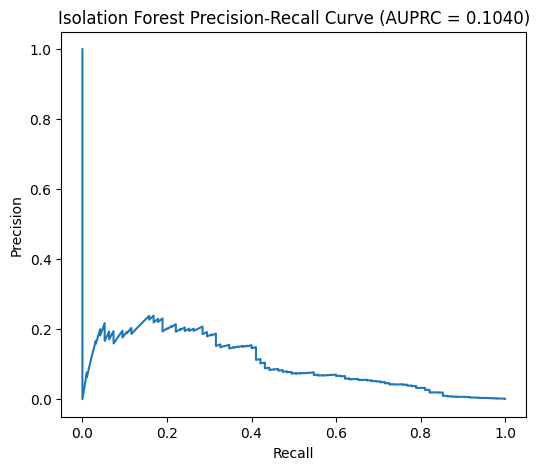

In [3]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

auprc_iso = average_precision_score(y_test, fraud_scores)
print("Isolation Forest AUPRC:", auprc_iso)

precision_iso, recall_iso, _ = precision_recall_curve(y_test, fraud_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall_iso, precision_iso)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Isolation Forest Precision-Recall Curve (AUPRC = {auprc_iso:.4f})")
plt.show()

In [4]:
iso_forest_auto = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)

iso_forest_auto.fit(X_train)

anomaly_scores_auto = iso_forest_auto.decision_function(X_test)
fraud_scores_auto = -anomaly_scores_auto

auprc_iso_auto = average_precision_score(y_test, fraud_scores_auto)
print("Isolation Forest (auto contamination) AUPRC:", auprc_iso_auto)

Isolation Forest (auto contamination) AUPRC: 0.10400318095977332


Isolation Forest achieved an AUPRC of 0.1040, far below the supervised XGBoost model's 0.8139.
The precision-recall curve shows precision collapses quickly as recall increases, meaning most transactions flagged as anomalous are not actually fraud — the model is detecting statistical outliers, not fraud specifically.
Tested with both the exact known fraud rate (0.1665%) and scikit-learn's automatic contamination setting — both produced the identical AUPRC (0.1040), confirming this is a genuine limitation of the unsupervised approach on this dataset, not a tunable parameter issue.
This result directly demonstrates the value of labeled data: with only 378 fraud examples to learn from, XGBoost outperforms Isolation Forest by a wide margin, since anomalous does not reliably mean fraudulent in this dataset — some genuine transactions are naturally unusual without being fraud.

Confusion matrix for Isolation Forest

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, y_pred_iso, target_names=["Genuine", "Fraud"]))

cm_iso = confusion_matrix(y_test, y_pred_iso)
print("Confusion Matrix:")
print(cm_iso)

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.20      0.19      0.20        95

    accuracy                           1.00     56746
   macro avg       0.60      0.59      0.60     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56580    71]
 [   77    18]]


At default threshold, Isolation Forest catches only 18 of 95 fraud cases (19% recall) with 71 false alarms out of 89 flagged transactions (20% precision).
Direct comparison to XGBoost: Isolation Forest misses roughly 4 times more fraud (77 vs 20) and generates roughly 10 times more false alarms (71 vs 7).
This confirms, with concrete transaction counts rather than just an abstract AUPRC score, that unsupervised anomaly detection is substantially less effective than supervised learning on this dataset when labeled fraud examples are available.
The practical implication: Isolation Forest alone would not be a viable production fraud detector here. Its real value in this project is as a documented comparison point, and potentially as a fallback signal for the period before fraud labels become available in a real system — not as a standalone solution.

Save the Isolation Forest model

In [6]:
import joblib

joblib.dump(iso_forest, "../artifacts/isolation_forest_model.pkl")
print("Model saved.")

Model saved.


Conclusion

Isolation Forest achieved an AUPRC of 0.1040, substantially below XGBoost's 0.8139. At the default threshold, it caught only 18 of 95 fraud cases (19% recall) with 71 false alarms, compared to XGBoost's 75 fraud caught with only 7 false alarms. Testing with both the calculated fraud rate and scikit-learn's automatic contamination setting produced identical results, confirming this is a genuine limitation of the approach rather than a tunable parameter issue. The core reason is that statistical outliers in this dataset do not reliably correspond to fraud — some genuine transactions are naturally unusual without being fraudulent, and Isolation Forest has no way to distinguish between the two without labels. This result is not a failure of the project; it is a deliberate, quantified demonstration of why labeled supervised learning outperforms unsupervised anomaly detection when sufficient labeled data exists, and it establishes a realistic fallback comparison for scenarios where labels are delayed or unavailable. The model is saved to artifacts/isolation_forest_model.pkl for use in the cost-sensitive evaluation notebook.